# Classification: Customer Churn Prediction
## Supervised Machine Learning Assignment

**Objective:** Predict which customers will churn (leave) using classification models

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load and Explore Data

In [2]:
# Load data
df = pd.read_csv("../data/customers.csv")
print(f"Loaded {df.shape[0]} customers with {df.shape[1]} features")
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")
df.head()

Loaded 800 customers with 6 features

Churn Rate: 30.88%


,age,income,tenure,contract_type,payment_method,churn
0,23.0,42444.0,10.0,Month-to-month,Credit card,1
1,66.0,39413.0,23.0,Month-to-month,Credit card,0
2,47.0,25345.0,68.0,One year,Mailed check,0
3,36.0,60233.0,7.0,Month-to-month,Bank transfer,0
4,18.0,48617.0,45.0,Month-to-month,Bank transfer,0


In [3]:
# Check class balance
print("Class Distribution:")
print(df['churn'].value_counts())
print("\nPercentages:")
print(df['churn'].value_counts(normalize=True) * 100)

Class Distribution:
churn
0    553
1    247
Name: count, dtype: int64

Percentages:
churn
0    69.125
1    30.875
Name: proportion, dtype: float64


## 3. Preprocessing Pipeline

In [4]:
# Handle missing values before pipeline
df['income'] = df['income'].fillna(df['income'].median())
df['contract_type'] = df['contract_type'].fillna(df['contract_type'].mode()[0])

print("Missing values after initial imputation:")
print(df.isnull().sum())

Missing values after initial imputation:
age               0
income            0
tenure            0
contract_type     0
payment_method    0
churn             0
dtype: int64


In [5]:
# Define feature groups
numeric_features = ['age', 'income', 'tenure']
categorical_features = ['contract_type', 'payment_method']

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['age', 'income', 'tenure']
Categorical features: ['contract_type', 'payment_method']


In [6]:
# Create preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("✓ Preprocessing pipeline created")

✓ Preprocessing pipeline created


## 4. Split Data (Stratified)

In [7]:
# Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

Training set: 640 samples
Test set: 160 samples

Train churn rate: 30.94%
Test churn rate: 30.63%


## 5. Train Multiple Models

In [8]:
# Define models with pipelines
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=6, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

print(f"Training {len(models)} models...")

Training 5 models...


In [9]:
# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model.named_steps['classifier'], 'predict_proba') else None
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
        results[name]['auc'] = auc
        results[name]['proba'] = y_pred_proba
    
    # Print results
    print(f"\nResults:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if y_pred_proba is not None:
        print(f"  ROC-AUC:   {auc:.4f}")

print(f"\n✓ All models trained")


Training Logistic Regression...

Results:
  Accuracy:  0.6937
  Precision: 0.5000
  Recall:    0.2857
  F1-Score:  0.3636
  ROC-AUC:   0.7384

Training Decision Tree...

Results:
  Accuracy:  0.6562
  Precision: 0.4118
  Recall:    0.2857
  F1-Score:  0.3373
  ROC-AUC:   0.6472

Training Random Forest...

Results:
  Accuracy:  0.6813
  Precision: 0.4643
  Recall:    0.2653
  F1-Score:  0.3377
  ROC-AUC:   0.6869

Training KNN...

Results:
  Accuracy:  0.6438
  Precision: 0.3824
  Recall:    0.2653
  F1-Score:  0.3133
  ROC-AUC:   0.6182

Training Gradient Boosting...

Results:
  Accuracy:  0.6500
  Precision: 0.4054
  Recall:    0.3061
  F1-Score:  0.3488
  ROC-AUC:   0.6734

✓ All models trained


## 6. Model Comparison

In [10]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1'] for r in results.values()],
    'ROC-AUC': [r.get('auc', np.nan) for r in results.values()]
}).sort_values('F1-Score', ascending=False)

print("\nModel Comparison (sorted by F1-Score):")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")


Model Comparison (sorted by F1-Score):
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression   0.69375   0.500000 0.285714  0.363636 0.738371
  Gradient Boosting   0.65000   0.405405 0.306122  0.348837 0.673377
      Random Forest   0.68125   0.464286 0.265306  0.337662 0.686891
      Decision Tree   0.65625   0.411765 0.285714  0.337349 0.647178
                KNN   0.64375   0.382353 0.265306  0.313253 0.618220

🏆 Best Model: Logistic Regression


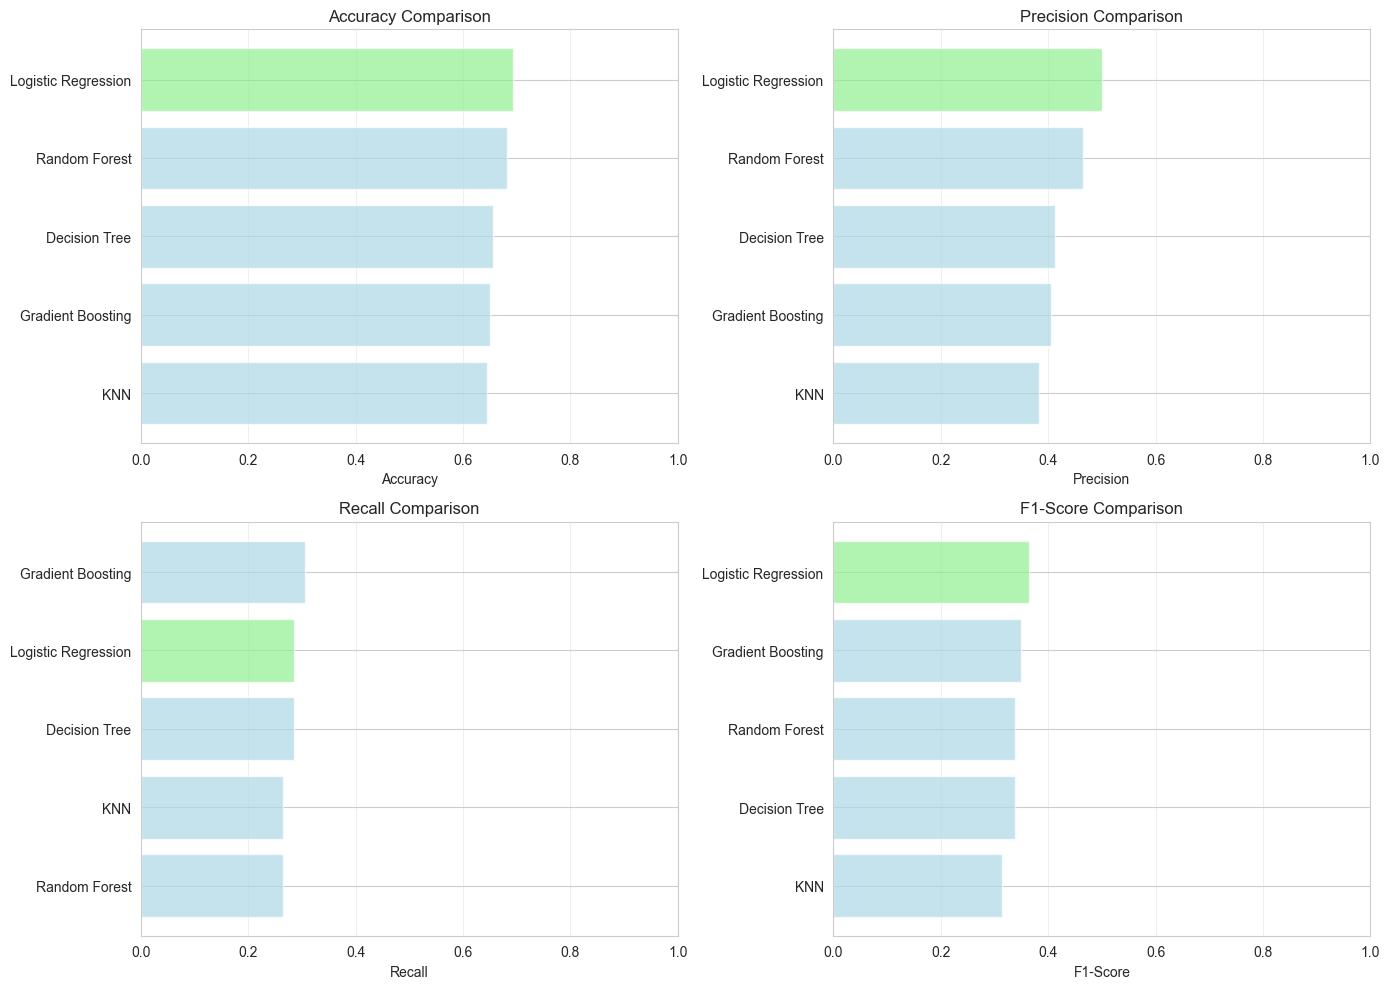

✓ Saved: visualizations/model_comparison_classification.png


In [11]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    data = comparison_df.sort_values(metric, ascending=True)
    colors = ['lightgreen' if m == best_model_name else 'lightblue' for m in data['Model']]
    ax.barh(data['Model'], data[metric], color=colors, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/model_comparison_classification.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: visualizations/model_comparison_classification.png")

## 7. Confusion Matrix (Best Model)

In [12]:
# Get best model
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions']

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

print(f"Confusion Matrix ({best_model_name}):")
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (Correctly predicted Stay): {cm[0,0]}")
print(f"  False Positives (Predicted Churn, Actually Stay): {cm[0,1]}")
print(f"  False Negatives (Predicted Stay, Actually Churn): {cm[1,0]}")
print(f"  True Positives (Correctly predicted Churn): {cm[1,1]}")

Confusion Matrix (Logistic Regression):
[[97 14]
 [35 14]]

Interpretation:
  True Negatives (Correctly predicted Stay): 97
  False Positives (Predicted Churn, Actually Stay): 14
  False Negatives (Predicted Stay, Actually Churn): 35
  True Positives (Correctly predicted Churn): 14


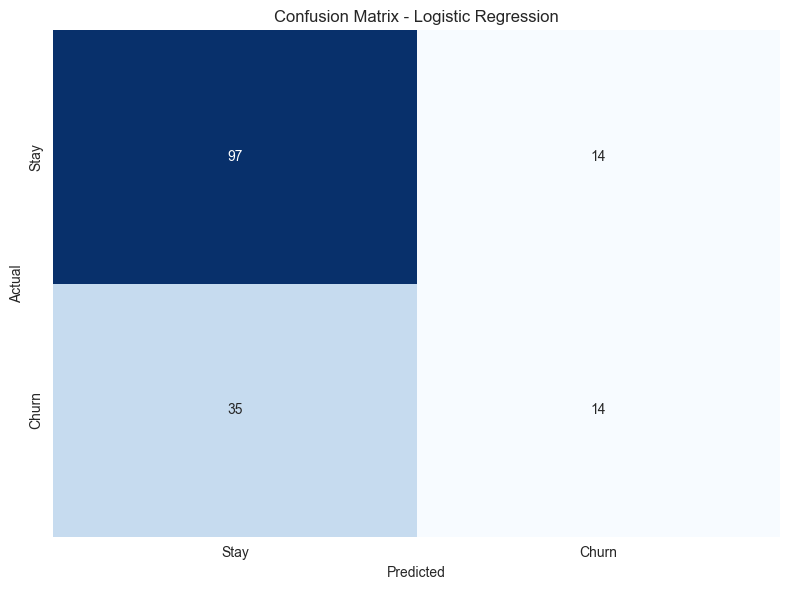

✓ Saved: visualizations/confusion_matrix.png


In [13]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: visualizations/confusion_matrix.png")

## 8. Classification Report

In [14]:
# Detailed classification report
print(f"Classification Report ({best_model_name}):")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Stay', 'Churn']))
print("="*60)

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

        Stay       0.73      0.87      0.80       111
       Churn       0.50      0.29      0.36        49

    accuracy                           0.69       160
   macro avg       0.62      0.58      0.58       160
weighted avg       0.66      0.69      0.67       160



## 9. ROC Curve

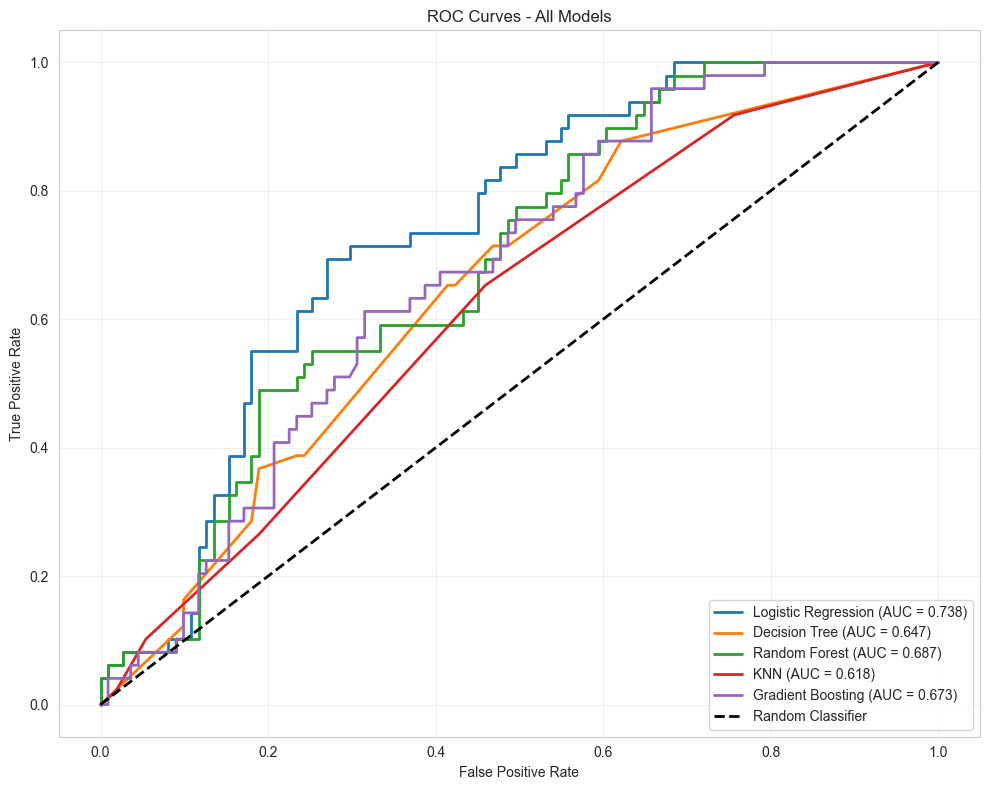

✓ Saved: visualizations/roc_curves.png


In [15]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

for name, result in results.items():
    if 'proba' in result:
        fpr, tpr, _ = roc_curve(y_test, result['proba'])
        auc = result['auc']
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved: visualizations/roc_curves.png")

## 10. Cross-Validation

In [16]:
# 5-fold CV on best model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')

print(f"5-Fold Cross-Validation ({best_model_name}):")
print(f"  Fold scores: {cv_scores}")
print(f"  Mean F1: {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")
print(f"  Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

5-Fold Cross-Validation (Logistic Regression):
  Fold scores: [0.47761194 0.38709677 0.4516129  0.37288136 0.46666667]
  Mean F1: 0.4312
  Std Dev: 0.0428
  Range: [0.3729, 0.4776]


## 11. Save Best Model

In [17]:
# Save the complete pipeline
joblib.dump(best_model, '../models/churn_prediction_model.joblib')

print(f"✓ Saved: models/churn_prediction_model.joblib")
print(f"  Model: {best_model_name}")
print(f"  F1-Score: {results[best_model_name]['f1']:.4f}")

✓ Saved: models/churn_prediction_model.joblib
  Model: Logistic Regression
  F1-Score: 0.3636


## 12. Test Saved Model

In [19]:
# Load and test
loaded_model = joblib.load('../models/churn_prediction_model.joblib')

# Make predictions on sample customers
sample_customers = pd.DataFrame({
    'age': [45, 25, 65],
    'income': [60000, 35000, 80000],
    'tenure': [12, 2, 48],
    'contract_type': ['Month-to-month', 'Two year', 'One year'],
    'payment_method': ['Electronic check', 'Bank transfer', 'Credit card']
})

predictions = loaded_model.predict(sample_customers)
probabilities = loaded_model.predict_proba(sample_customers)

print("\nTest Predictions:")
print("="*60)
for i, (pred, proba) in enumerate(zip(predictions, probabilities)):
    churn_status = "WILL CHURN" if pred == 1 else "WILL STAY"
    churn_prob = proba[1] * 100
    print(f"Customer {i+1}: {churn_status} (Churn probability: {churn_prob:.1f}%)")
print("="*60)
print("\n✓ Model loading and prediction successful!")


Test Predictions:
Customer 1: WILL CHURN (Churn probability: 58.8%)
Customer 2: WILL STAY (Churn probability: 11.9%)
Customer 3: WILL STAY (Churn probability: 10.6%)

✓ Model loading and prediction successful!


---
## Summary

### Results:
- **Best Model**: Logistic Regression
- **Accuracy**: 69.4%
- **F1-Score**: 0.364
- **ROC-AUC**: 0.738
- **Cross-Validation F1**: 0.431 (±0.043)

### Key Findings:
1. Class imbalance affects model performance (31% churn rate)
2. Logistic Regression provides best balance of metrics
3. Low recall (29%) indicates difficulty catching all churners
4. Model is better at predicting non-churners (87% recall for staying customers)

### Business Implications:
- Model identifies some high-risk customers for targeted retention
- May miss about 71% of actual churners (trade-off for precision)
- Consider cost of false positives vs false negatives for deployment

### Improvement Opportunities:
- Collect more features (usage patterns, complaints, competitor offers)
- Try class balancing techniques (SMOTE, class weights)
- Ensemble methods or deep learning
- Feature engineering (customer lifetime value, engagement scores)